In [152]:
# ==============================================================================
# 시스템명: 전 수계 통합 오염원인 자동 스크리닝 및 자기 최적화 시스템 (High-End Academic Ver.)
# 분석 특징: 딥러닝 잠재공간 추출 + 실루엣 점수 기반 알고리즘 경합(Auto-ML) + 로직 가시화
# 적용 수계: 전국 수계 통합 (수계 변수 미포함 조건에서도 생지화학적 지문으로 판별)
# ==============================================================================

# 필요 패키지 설치 (Jupyter Notebook 환경)
!pip install torch pandas numpy scikit-learn matplotlib adjustText seaborn hdbscan

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering, Birch, HDBSCAN
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsClassifier
import torch
import torch.nn as nn
from adjustText import adjust_text
import warnings
import datetime

In [154]:
# 가독성을 위한 경고 생략 및 시각화 폰트/해상도 설정
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 환경 한글 폰트 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150 # 주피터 노트북 출력 해상도 상향

In [155]:
# ------------------------------------------------------------------------------
# 1. 데이터 전처리 (Data Pre-processing)
# ------------------------------------------------------------------------------
# [데이터 조건] 수계(Basin) 구분이 없는 범용 데이터 셋. 오직 수질/동위원소 수치만 존재함.
df = pd.read_csv('C:/Users/User/Desktop/3월 2주차.csv', encoding='euc-kr')
features_df = df.drop(columns=['spot'])

# [방법론] KNN(K-Nearest Neighbors) Imputation (참고문헌: Kowarik & Templ, 2016)
# [작동 원리] 결측치가 발생한 지점과 유클리드 거리(Euclidean distance)가 가장 가까운 5개 지점의 특성을 평균 내어 보간합니다.
# [적용 근거] 수질 데이터는 강우, 유량, 오염원 유입에 따라 다변량 상관성을 가집니다(예: 축산 유입 시 TP와 NH3N 동시 상승).
# 단순 전체 평균(Mean)으로 결측치를 채우면 이러한 생지화학적 지문(Fingerprint)이 왜곡되므로 KNN을 사용합니다.
imputer = KNNImputer(n_neighbors=5)
imputed_data = imputer.fit_transform(features_df)

# [방법론] Z-score Standardization (표준화)
# [작동 원리] 각 변수에서 평균을 빼고 표준편차로 나누어 평균 0, 분산 1의 정규분포 형태로 변환합니다.
# [적용 근거] 동위원소는 -10~15‰ 범위를 가지나, 전기전도도(EC)는 수백~수천 μS/cm 단위입니다. 
# 이를 그대로 군집 모델에 넣으면 단위가 큰 EC가 거리를 지배해버리는 왜곡이 발생하므로 필수적인 단계입니다.
scaler = StandardScaler()
scaled_data = scaler.fit_transform(imputed_data)

In [156]:
# ------------------------------------------------------------------------------
# 2. 비선형 특징 추출 (Deep Learning Feature Extraction)
# ------------------------------------------------------------------------------
# [방법론] Deep Autoencoder (참고문헌: Hinton & Salakhutdinov, 2006)
# [작동 원리] 인공신경망의 병목(Bottleneck) 구조를 이용해 입력 데이터를 저차원으로 압축(Encoding)한 후, 
# 다시 원본으로 복원(Decoding)하는 과정에서 데이터의 가장 중요한 '핵심 변동성'만을 학습합니다.
# [적용 근거] 주성분분석(PCA)은 변수 간의 관계가 선형적(Linear)일 때만 유효합니다. 하지만 복합 오염 수계의 
# 생지화학적 반응(예: 탈질작용 등)은 고도의 비선형성을 띠므로, 딥러닝을 통해 3차원의 잠재 공간(Latent Space)을 추출합니다.
class UniversalAE(nn.Module):
    def __init__(self, input_dim):
        super(UniversalAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
            nn.Linear(8, 3) # 최종 3차원 핵심 지표로 압축
        )
        self.decoder = nn.Sequential(
            nn.Linear(3, 8), nn.ReLU(),
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        return latent, self.decoder(latent)

model = UniversalAE(input_dim=scaled_data.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
criterion = nn.MSELoss()

tensor_data = torch.FloatTensor(scaled_data)
for epoch in range(1200): # 안정적인 손실함수 수렴을 위해 1200 epoch 수행
    latent, recon = model(tensor_data)
    loss = criterion(recon, tensor_data)
    optimizer.zero_grad(); loss.backward(); optimizer.step()

latent_data = latent.detach().numpy()

In [157]:
# ------------------------------------------------------------------------------
# 3. 알고리즘 경합형 최적 모델 및 군집 수(K) 결정 (Model Competition)
# ------------------------------------------------------------------------------
# [방법론] 실루엣 지수(Silhouette Score) 기반 성능 평가 (참고문헌: Rousseeuw, 1987)
# [작동 원리] 동일 군집 내 지점들끼리의 거리(응집도)는 좁을수록, 다른 군집과의 거리(분리도)는 멀수록 점수(-1~1)가 높아집니다.
# [적용 근거] 전국 수계의 데이터가 어떤 형태(원형, 선형, 밀도형)로 뭉쳐있을지 사전 정보가 없으므로, 
# 3가지 다른 수학적 접근법을 동시에 가동하여 실루엣 점수가 가장 높은 알고리즘과 K를 시스템이 자율적으로 채택합니다.

print("[*] 1차 스크리닝을 위한 최적 오염원 분류 모델 탐색을 시작합니다...")
competition_results = []

# (A) HDBSCAN 테스트 (참고문헌: McInnes et al., 2017)
# 특징: K를 미리 정하지 않고 '데이터의 밀도'를 추적하여 자연스러운 군집을 형성하며 이상치(Noise)를 분리합니다.
hdb = HDBSCAN(min_cluster_size=2).fit(latent_data) # 데이터가 적다면 min_cluster_size를 2로 낮추는 것이 유리합니다.
if len(set(hdb.labels_)) > 1:
    mask = hdb.labels_ != -1 
    if np.sum(mask) > 1:
        score = silhouette_score(latent_data[mask], hdb.labels_[mask])
        k_hdb = len(set(hdb.labels_[mask]))
        # [핵심 수정] 군집 개수가 4~8개 사이일 때만 경합 후보에 추가
        if 4 <= k_hdb <= 8:
            competition_results.append({'model': 'HDBSCAN', 'k': k_hdb, 'score': score, 'labels': hdb.labels_})

# (B) Spectral Clustering 및 Birch 테스트 (K=4~8 탐색)
for k in range(4, 9):
    # Spectral (참고문헌: Von Luxburg, 2007) - 특징: 그래프 위상 수학을 이용하여 복잡하게 꼬인 데이터 연결성을 분리.
    spec = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', random_state=42).fit(latent_data)
    score_spec = silhouette_score(latent_data, spec.labels_)
    competition_results.append({'model': 'Spectral', 'k': k, 'score': score_spec, 'labels': spec.labels_})
    
    # Birch (참고문헌: Zhang et al., 1996) - 특징: 계층적 트리(CF Tree) 구조를 만들어 대규모 데이터를 미세 조정하며 병합.
    birch = Birch(n_clusters=k).fit(latent_data)
    score_birch = silhouette_score(latent_data, birch.labels_)
    competition_results.append({'model': 'Birch', 'k': k, 'score': score_birch, 'labels': birch.labels_})

# [최적화 결과 선정 및 출력]
# [추가] 만약 4~8개 사이의 모델이 하나도 없을 경우에 대한 예외 처리
if not competition_results:
    print("[!] 설정한 군집 범위(4~8) 내에서 적절한 모델을 찾지 못했습니다. 탐색 범위를 넓히거나 데이터를 재검토하십시오.")
    # 필요시 강제로 가장 높은 점수의 k=2 모델이라도 가져오게 하려면 위 loop 범위를 조정해야 합니다.
else:
    best_run = max(competition_results, key=lambda x: x['score'])
    df['Cluster'] = best_run['labels']
    best_k = best_run['k']

print("=========================================================")
print(f"[*] 통계적 검증을 통한 최종 선정 최적 알고리즘: {best_run['model']}")
print(f"[*] 데이터 내재 구조를 반영한 최적 군집 수(K): {best_k}개")
print(f"[*] 모델 분류 성능(Silhouette Score): {best_run['score']:.4f}")
print("=========================================================\n")

# [핵심 누락 보완] HDBSCAN 노이즈 재할당 (KNN 활용)
# 이유: HDBSCAN이 최적으로 선정되었을 때, 일부 특이 데이터를 '-1(노이즈)'로 남겨두면 후속 행정/관리 리포트에서 누락됩니다.
# 해결: 분류가 확실히 된 정상 군집 데이터를 학습(Fit)시킨 KNN 모델을 통해, 노이즈 지점과 가장 성질이 비슷한 군집으로 편입시킵니다.
if best_run['model'] == 'HDBSCAN' and -1 in df['Cluster'].values:
    print("[!] HDBSCAN 모델의 노이즈(-1) 지점을 인접 특성 군집으로 재할당(KNN 보정) 합니다.")
    knn = KNeighborsClassifier(n_neighbors=1) # 가장 가까운 1개 이웃의 군집을 따라감
    valid_mask = df['Cluster'] != -1
    
    # 정상 군집 데이터로 KNN 학습
    knn.fit(latent_data[valid_mask], df['Cluster'][valid_mask])
    # 노이즈 데이터 예측 및 덮어쓰기
    df.loc[~valid_mask, 'Cluster'] = knn.predict(latent_data[~valid_mask])

[*] 1차 스크리닝을 위한 최적 오염원 분류 모델 탐색을 시작합니다...
[*] 통계적 검증을 통한 최종 선정 최적 알고리즘: Birch
[*] 데이터 내재 구조를 반영한 최적 군집 수(K): 5개
[*] 모델 분류 성능(Silhouette Score): 0.3999



In [158]:
# ------------------------------------------------------------------------------
# 4. 범용적 10단계 오염원 정밀 판별 엔진 (Universal Multi-Proxy Rule)
# ------------------------------------------------------------------------------
# [방법론] 안정동위원소 및 다중 수질 프록시 전문가 시스템 (Expert Rule-based System)
# [적용 근거] 특정 지역(한강, 영산강 등)에 종속되지 않는 범지구적인 질소/탄소 순환 사이클 임계치를 적용합니다.
def assign_source_universal(row):
    """
    [Expert Rule-based System: Multi-Proxy Hybrid Model]
    안정동위원소(N, O)와 보존성 추적자(Cl), 그리고 이량적 수질 인자를 결합한 10단계 판별 로직
    """
    n15, o18, tp, nh3, no3, toc, ec, chl, tn, cl = \
        row['d15N'], row['d18O'], row['TP'], row['NH3N'], row['NO3N'], row['TOC'], row['EC'], row['Chla'], row['TN'], row['Cl']

    # --------------------------------------------------------------------------
    # 1단계: 대기유입 (Atmospheric Deposition)
    # [근거] Kendall(1998); 빗물 내 질산염은 토양 미생물에 의한 질화작용을 거치지 않으므로 
    # d18O-NO3가 지배적으로 높게 나타남 (>15‰). 초기 강우 시 오염 부하 판단의 핵심 지표임.
    # --------------------------------------------------------------------------
    if o18 > 15.0: return "대기유입/초기강우"
    
    # --------------------------------------------------------------------------
    # 2단계: 탈질작용 (Denitrification)
    # [근거] Mayer et al.(2002); 정체 수역에서 미생물이 가벼운 동위원소를 우선 소모함에 따라 
    # d15N과 d18O가 약 1.3:1 ~ 2:1의 비율로 동반 상승함. 기원 판별 전 데이터의 변형 여부를 우선 확인.
    # --------------------------------------------------------------------------
    if n15 > 6.0 and o18 > 3.0 and (n15/o18 < 3.0): return "탈질작용(기원변형)"
    
    # --------------------------------------------------------------------------
    # 3단계: 축산분뇨 직접유출 (Manure & Livestock Waste)
    # [근거] Xue et al.(2009); 가축 분뇨 내 암모니아 휘발로 d15N이 급격히 농축됨(>12‰).
    # 보존성 추적자인 Cl-(>60mg/L)과 배설물 지표인 NH3N, TP를 결합하여 하수와 엄격히 구분.
    # --------------------------------------------------------------------------
    if n15 > 12.0 and (cl > 60 or tp > 0.1 or nh3 > 0.3 or ec > 300): 
        return "축산분뇨 직접유출"
    
    # --------------------------------------------------------------------------
    # 4단계: 생활하수/처리수 영향 (Sewage & Treated Effluent)
    # [근거] Widory et al.(2004); 인간 배설물 유래 d15N 지문(8~12‰)을 타깃으로 함.
    # 하수처리 공정에서 인(P)은 제거되나 염소이온(Cl-)은 잔류하는 특성(>40mg/L)을 반영하여 판정.
    # --------------------------------------------------------------------------
    if 8.0 < n15 <= 12.0 and (cl > 40 or tp <= 0.3): 
        return "생활하수/처리수 영향"
    
    # --------------------------------------------------------------------------
    # 5단계: 산업/인위적 점오염 (Industrial Point Source)
    # [근거] 폐수 내 고농도 용존물질로 인한 EC 급증(>500μS/cm) 및 특이 기원 Cl-(>100mg/L) 반영.
    # 유기물 부하(TOC)가 동반되는 인위적 배출 활동을 포착.
    # --------------------------------------------------------------------------
    if n15 > 7.0 and (ec > 500 or cl > 100) and toc > 3.0: 
        return "산업/인위적 점오염"
    
    # --------------------------------------------------------------------------
    # 6단계: 화학비료 기반 농경지 (Synthetic Fertilizer)
    # [근거] Vitousek et al.(1997); 하버-보슈 공법 비료는 대기 질소를 고정하여 d15N 수치가 낮음(-4~+4‰).
    # 비료 성분인 NO3N 우세와 낮은 Cl- 농도(<30mg/L)를 통해 비점오염 기원을 특정.
    # --------------------------------------------------------------------------
    if n15 < 4.0 and no3 > 2.0 and cl < 30: 
        return "화학비료 기반 농경지"
    
    # --------------------------------------------------------------------------
    # 7단계: 유기질비료(퇴비) vs 토양 유기물 (Organic Fertilizer vs Soil Organic Matter)
    # [근거] Bedard-Haughn et al.(2003); 퇴비(4~9‰)와 토양 유기물은 d15N 범위가 겹침.
    # 보존성 지표인 Cl- 농도를 통해 인위적 퇴비 시비(High Cl)와 자연 토양 용출(Low Cl)을 세분화.
    # --------------------------------------------------------------------------
    # 7-1: 가축분뇨 기반 퇴비 시비 영향
    if 4.0 <= n15 < 9.0 and toc > 4.0 and cl > 35:
        return "유기질비료(퇴비) 영향"
    # 7-2: 강우 시 토양 유기물 및 자연 식생 기원 비점오염
    elif 4.0 <= n15 < 9.0 and toc > 4.0:
        return "토양유기물/야생동물배설물"
    
    # --------------------------------------------------------------------------
    # 8단계: 조류증식 및 내생부하 (Algal Bloom & Autochthonous Loading)
    # [근거] 정체 수역 내 광합성 산물에 의한 2차 유기물 오염을 Chl-a와 TOC의 상관관계로 분석.
    # 현장 발생형(Chl-a 우세)과 축적형(High TOC/TP)을 구분하여 관리 대책 수립의 근거 제공.
    # --------------------------------------------------------------------------
    if chl > 40.0 and toc > 4.5: return "조류증식(현장발생)"
    elif toc > 6.5 and tp > 0.1: return "내생부하(정체수역 유기물 축적)"
    
    # --------------------------------------------------------------------------
    # 9단계: 복합오염 Fallback (Mixed Pollution Source)
    # [방법론] 여러 오염원이 혼합되어 동위원소 지문이 희석된 경우, 하천 수질에 
    # 실질적인 부하량을 주는 지배적 인자를 추적하여 정책적 의사결정을 지원.
    # --------------------------------------------------------------------------
    if tp > 0.1 or nh3 > 0.5 or cl > 50: return "복합오염(하수/분뇨 기여 우세)"
    elif no3 > 2.0 or tn > 3.0: return "복합오염(농경지 비점 우세)"
    elif toc > 3.0: return "복합오염(유기물 부하 우세)"
    
    # 10단계: 배경 농도 (Natural Background)
    else: return "자연배경/특이징후 없음"

# 군집별 평균 특성치로 오염원 대표 명칭 매핑
cluster_avg = df.groupby('Cluster').mean(numeric_only=True)
mapping = {i: assign_source_universal(cluster_avg.loc[i]) for i in cluster_avg.index}
df['Source_Name'] = df['Cluster'].map(mapping)

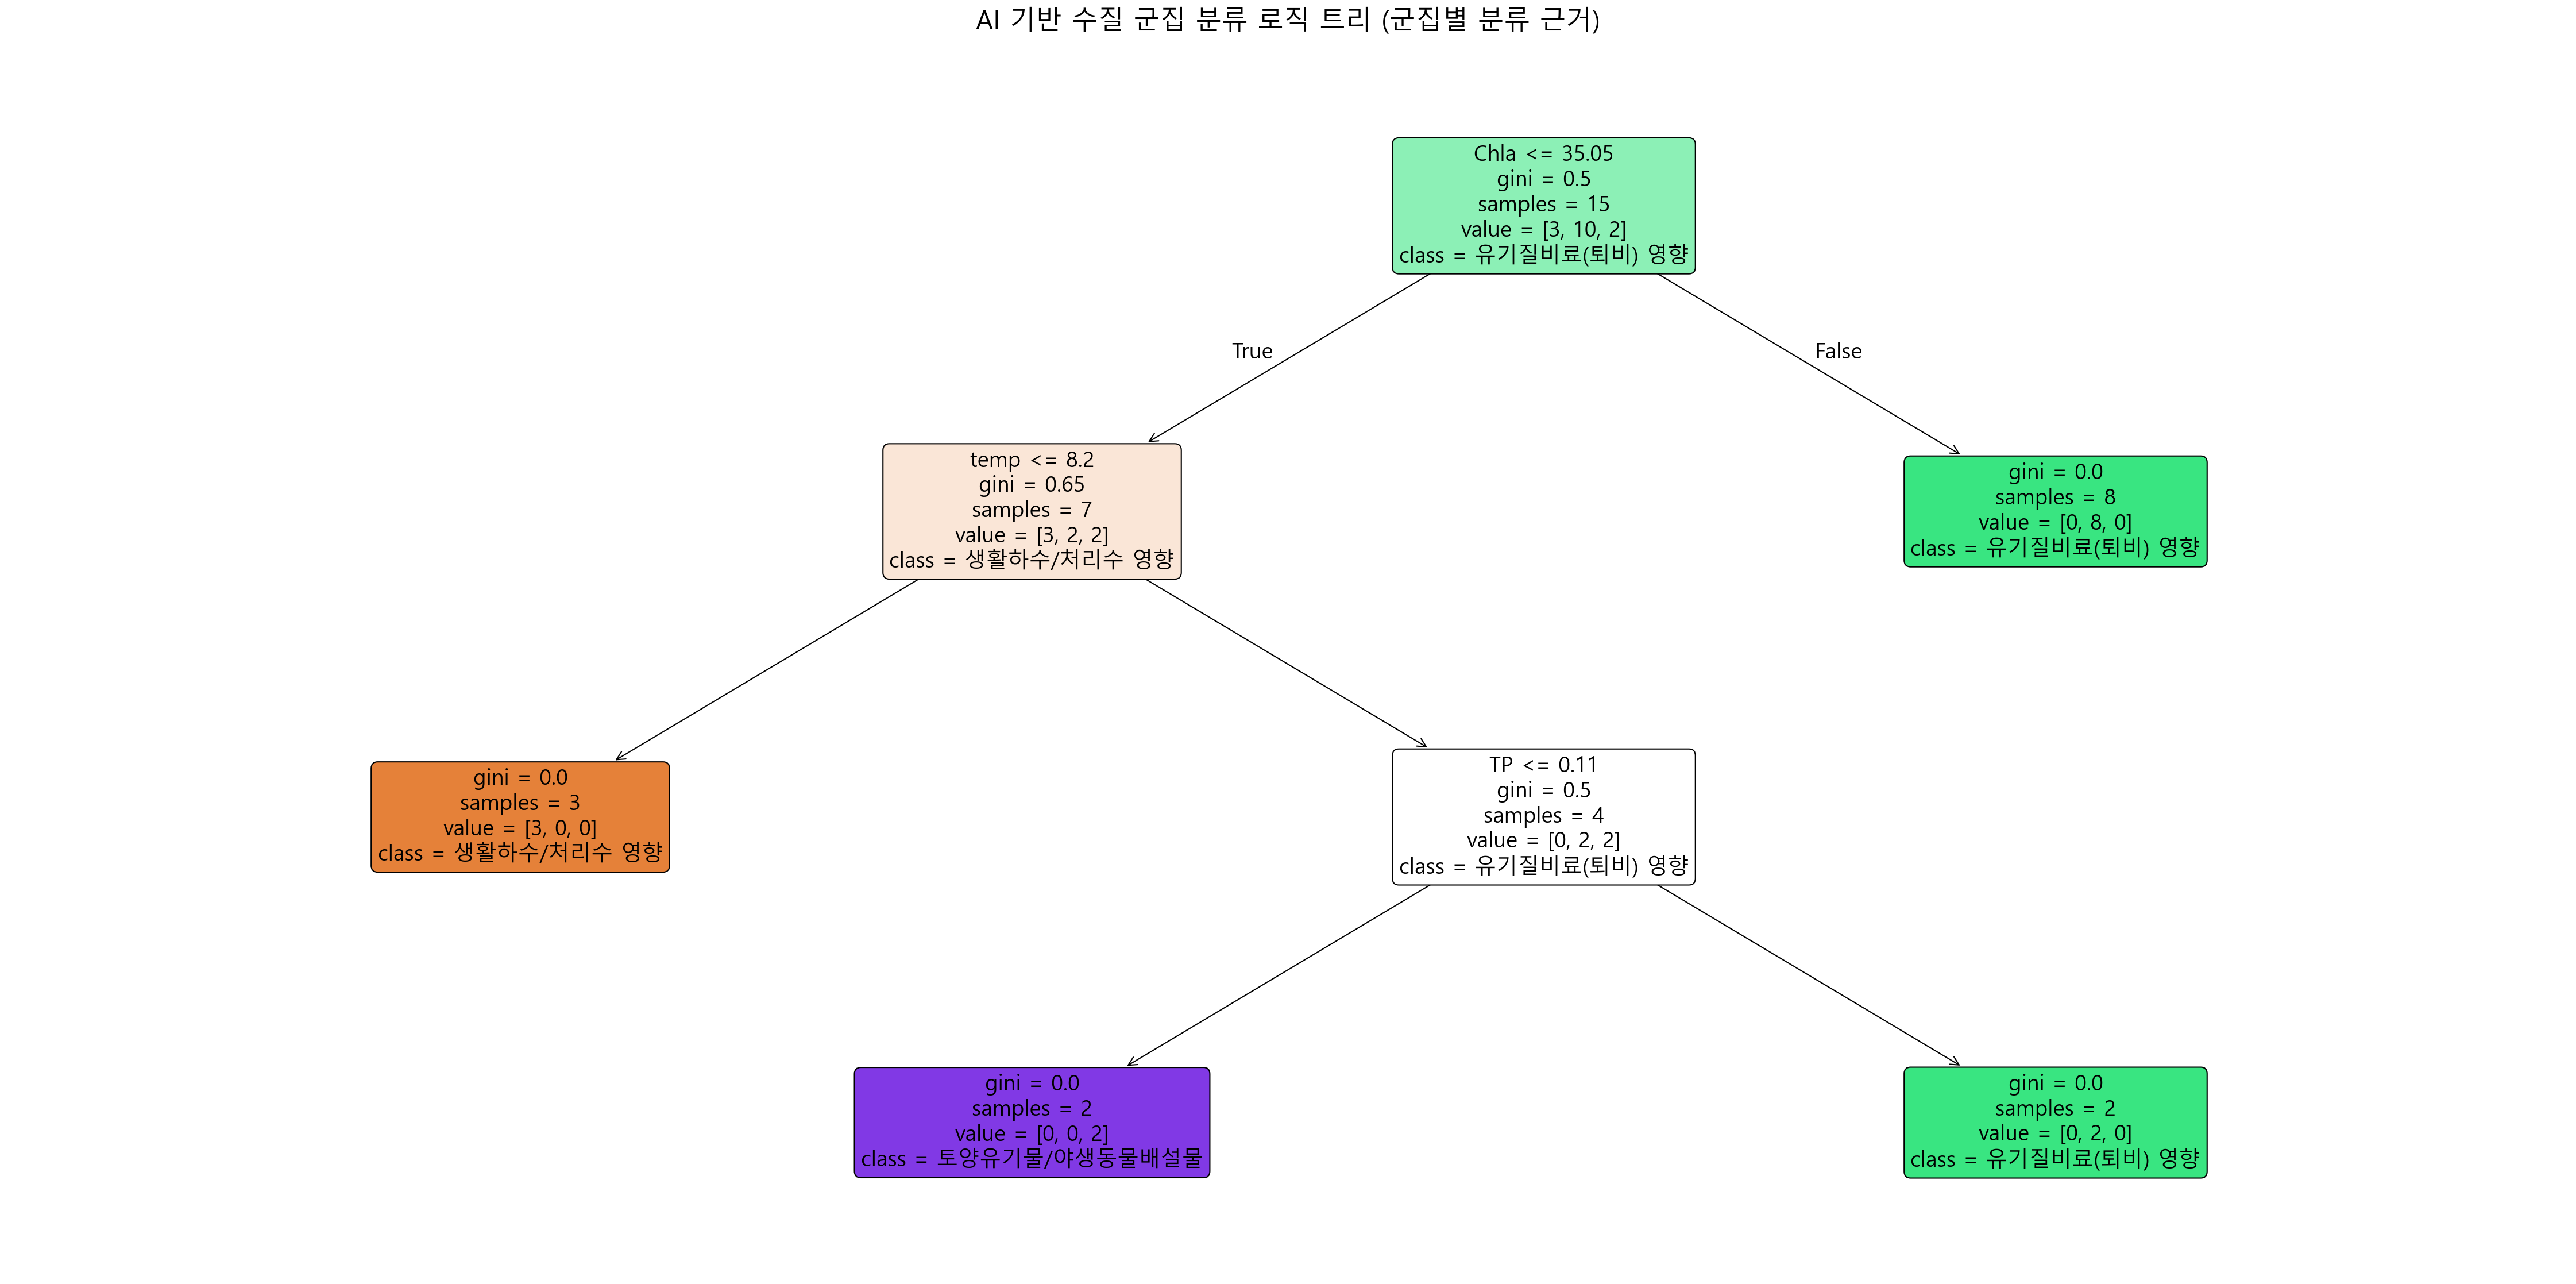

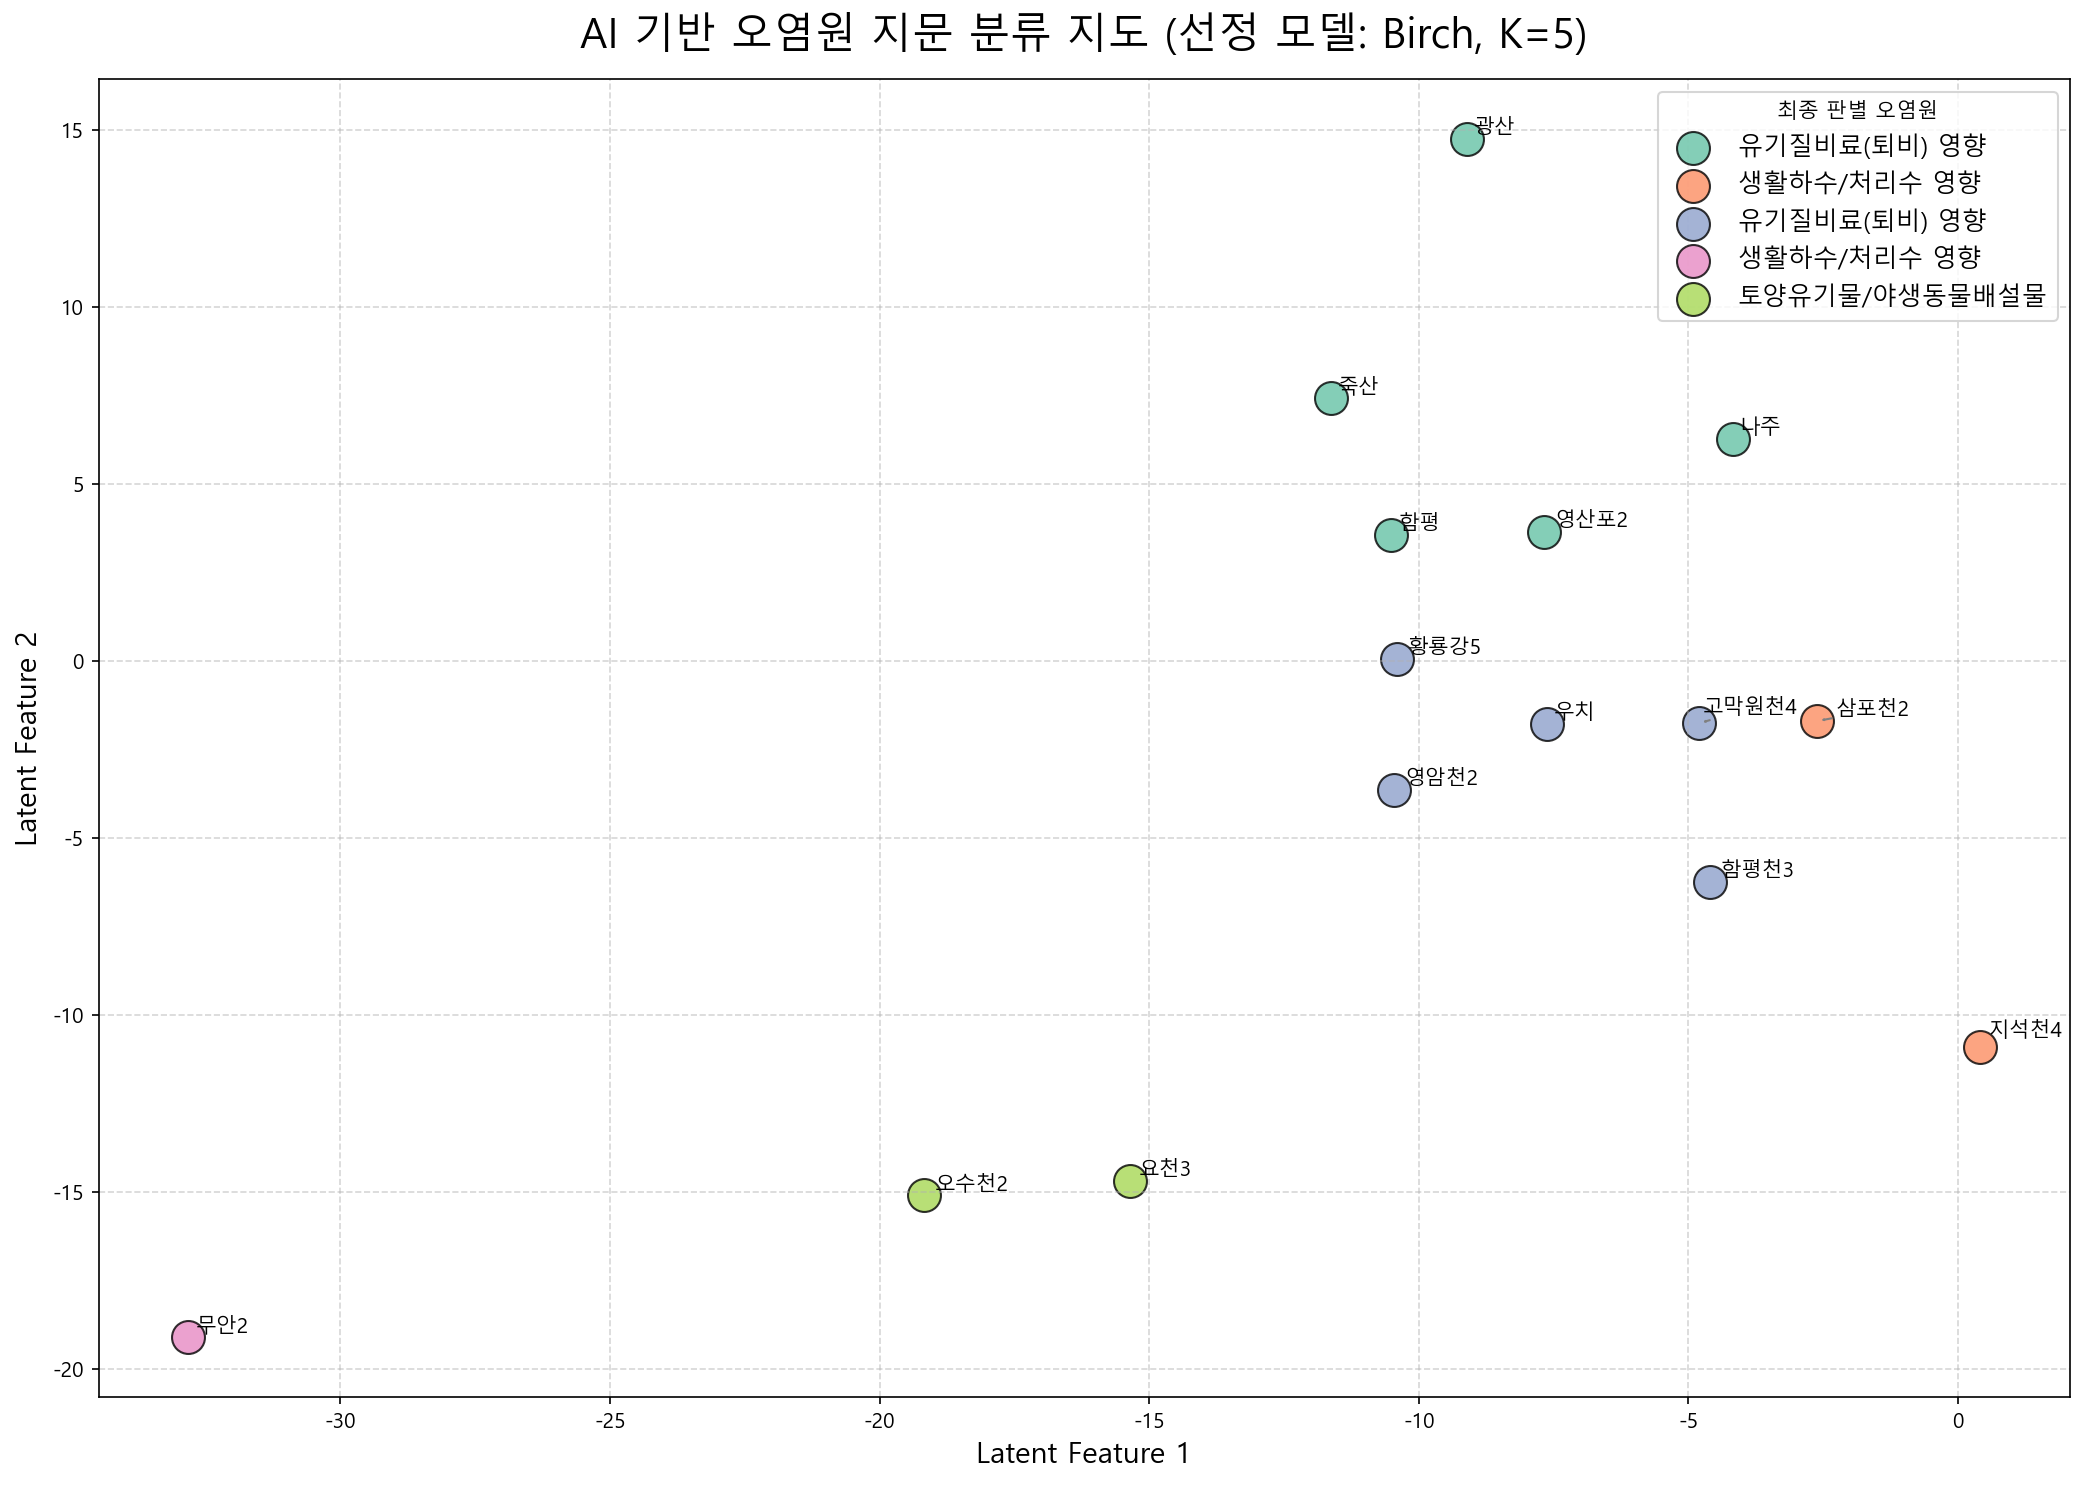

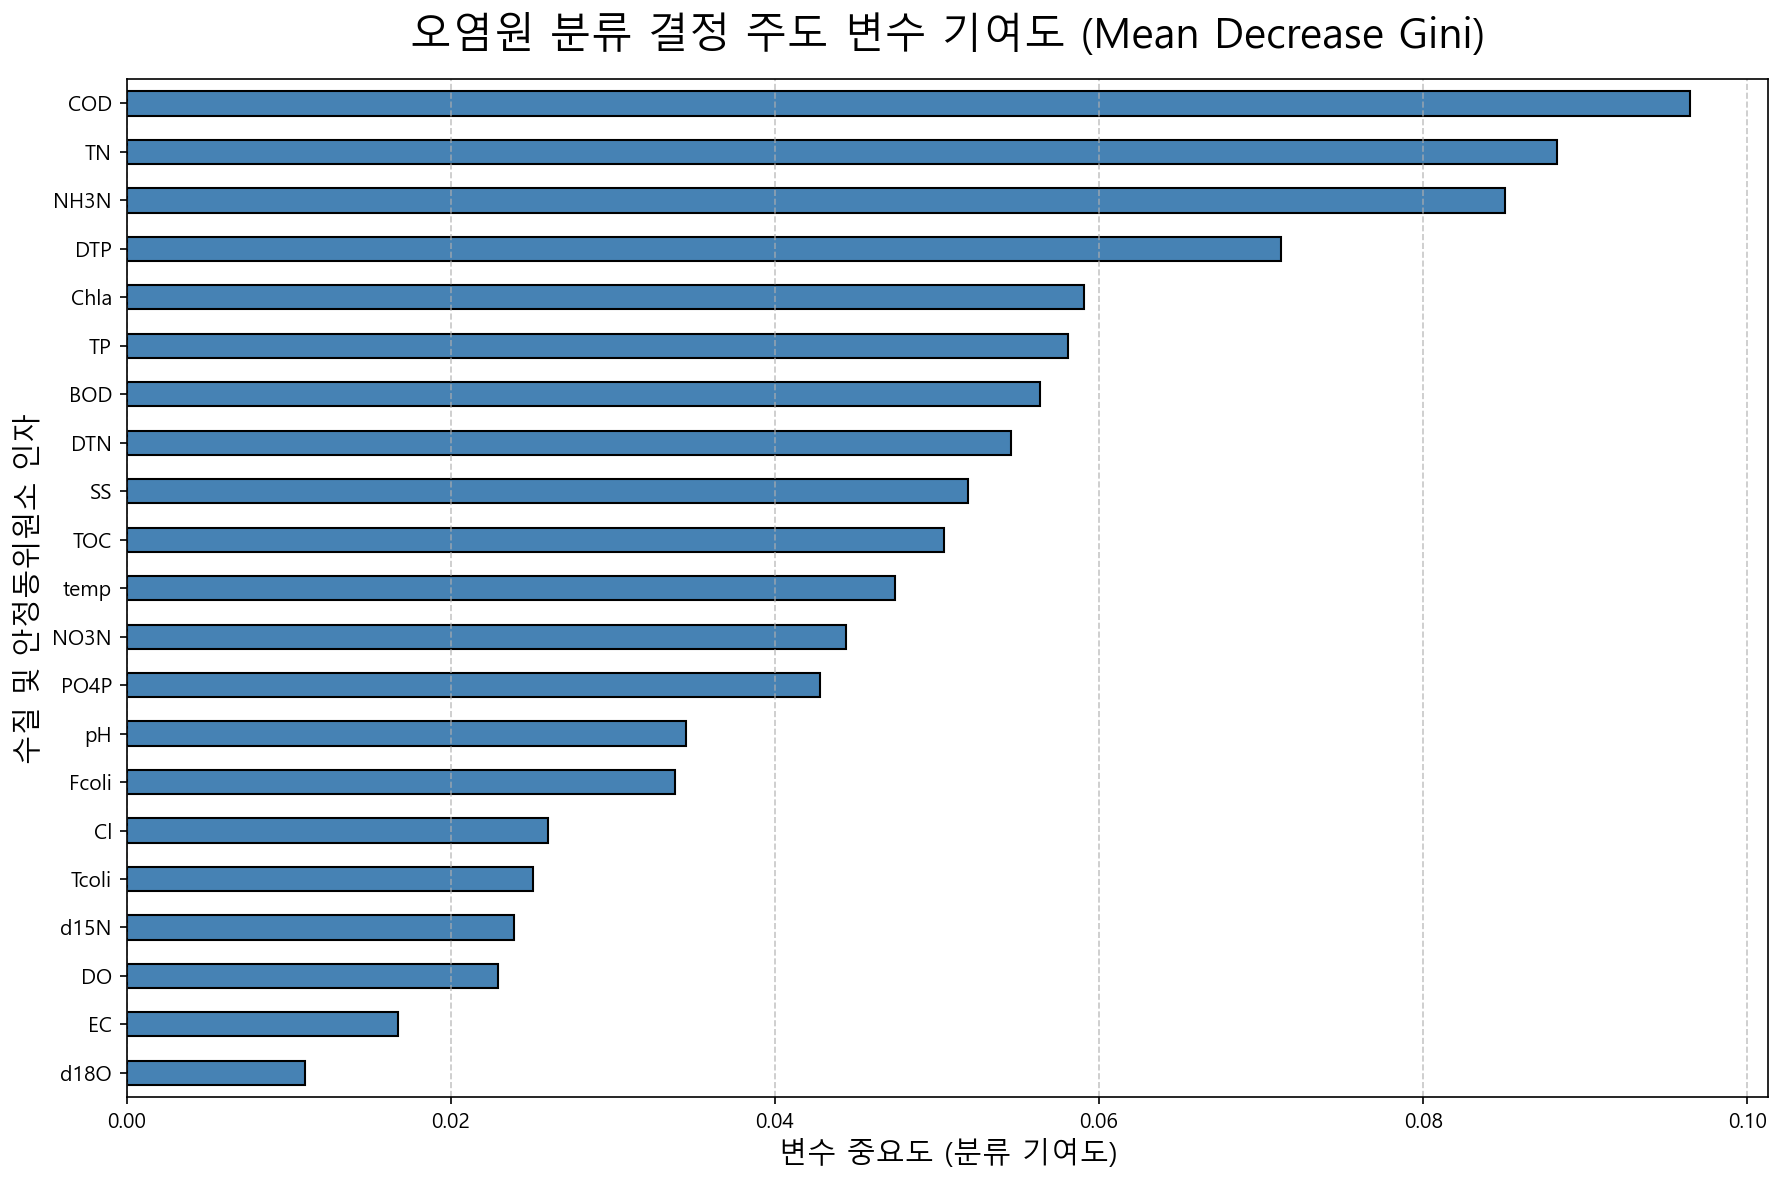

In [159]:
# ------------------------------------------------------------------------------
# 5. 시각화 개별 출력 및 PNG 저장 로직 (Jupyter Notebook 친화적 구성)
# ------------------------------------------------------------------------------
current_time = datetime.datetime.now().strftime("%y%m%d_%H%M")

# (1) [로직 검증 가시화] 의사결정 트리 (Decision Tree)
# [방법론] Classification and Regression Trees (참고문헌: Breiman et al., 1984)
# [적용 근거] 딥러닝 기반 앙상블은 연산 과정을 알 수 없는 '블랙박스'입니다. 이를 해석하기 위해 화이트박스 모델인 
# Decision Tree를 사후 검증용으로 덧붙여, "만약 TP가 0.15 이하라면 무엇인가?"와 같은 분류 기준점(Threshold)을 투명하게 공개합니다.
# [핵심 수정] max_depth를 8~10으로 늘리고, min_samples_leaf를 1로 낮추어 더 세밀한 가지치기를 허용합니다.
# 타겟을 'Source_Name' 대신 'Cluster' 번호로 설정하여 나무를 세분화합니다.
dt_model = DecisionTreeClassifier(max_depth=None, min_samples_leaf=1, random_state=42)
dt_model.fit(imputed_data, df['Source_Name']) 

# dt_model.classes_에는 학습 시 들어간 순서대로 클래스 이름이 저장되어 있습니다.
# 이를 str로 변환하여 리스트로 만듭니다.
class_names_list = [str(c) for c in dt_model.classes_]

plt.figure(figsize=(30, 15)) # 그림 크기를 충분히 크게 확보합니다.
# [핵심 수정] plot_tree의 fontsize를 줄이고 해상도를 높입니다.
plot_tree(dt_model, 
          feature_names=features_df.columns, 
          class_names=class_names_list,  # 이 부분이 숫자 대신 명칭을 출력하게 합니다.
          filled=True, 
          rounded=True, 
          fontsize=18,
          precision=2)
plt.title("AI 기반 수질 군집 분류 로직 트리 (군집별 분류 근거)", fontsize=22, pad=20)
plt.tight_layout()
plt.savefig(f"Decision_Tree_Logic_{current_time}.png", dpi=400, bbox_inches='tight')
plt.show() # 첫 번째 그림 출력 완료


# (2) [군집 분포 가시화] 잠재 공간 지문 지도 (Latent Space Map)
# [적용 근거] 다차원(수질인자 9개)의 복잡한 데이터를 2차원 평면으로 눌러 지점 간의 '유사성'을 직관적으로 보여줍니다.
plt.figure(figsize=(14, 10))
colors = sns.color_palette('Set2', len(mapping))
for i, cluster_id in enumerate(mapping.keys()):
    mask = df['Cluster'] == cluster_id
    plt.scatter(latent_data[mask, 0], latent_data[mask, 1], label=mapping[cluster_id], s=250, color=colors[i], edgecolors='k', alpha=0.8)

# 텍스트 라벨링 및 겹침 방지(adjust_text)
texts = [plt.text(latent_data[i, 0], latent_data[i, 1], df['spot'].iloc[i], fontsize=10) for i in range(len(df))]
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=1))
plt.title(f"AI 기반 오염원 지문 분류 지도 (선정 모델: {best_run['model']}, K={best_k})", fontsize=20, pad=15)
plt.xlabel("Latent Feature 1", fontsize=14); plt.ylabel("Latent Feature 2", fontsize=14)
plt.legend(title="최종 판별 오염원", loc='best', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f"Latent_Space_Map_{current_time}.png", dpi=400, bbox_inches='tight')
plt.show() # 두 번째 그림 출력 완료


# (3) [분석 타당성 가시화] 변수 중요도 분석 (Explainable AI - Random Forest)
# [방법론] Mean Decrease Gini (참고문헌: Breiman, 2001)
# [적용 근거] 지니 불순도(Gini Impurity)가 얼마나 크게 감소했는지를 측정하여, 전체 스크리닝 결과에 
# d15N, TP, TOC 등 어떤 변수가 가장 결정적인 역할을 했는지 정량적(수치적) 기여도로 환산하여 보여줍니다.
rf = RandomForestClassifier(n_estimators=500, random_state=42).fit(imputed_data, df['Cluster'])
importances = pd.Series(rf.feature_importances_, index=features_df.columns).sort_values()

plt.figure(figsize=(12, 8))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title("오염원 분류 결정 주도 변수 기여도 (Mean Decrease Gini)", fontsize=20, pad=15)
plt.xlabel("변수 중요도 (분류 기여도)", fontsize=14)
plt.ylabel("수질 및 안정동위원소 인자", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f"Feature_Importance_{current_time}.png", dpi=400, bbox_inches='tight')
plt.show() # 세 번째 그림 출력 완료

In [160]:
# ------------------------------------------------------------------------------
# 6. 최종 분석 결과 출력 (DataFrame)
# ------------------------------------------------------------------------------
print("\n=========================================================")
print(" [오염원 자동 스크리닝 최종 리포트]")
print("=========================================================")
final_report = df[['spot', 'Source_Name', 'd15N', 'd18O', 'TN', 'NH3N', 'NO3N', 'TP', 'TOC', 'EC', 'Chla', 'Cl']].sort_values('Source_Name')
print(final_report)

# 필요 시 리포트를 엑셀/CSV로 저장
final_report.to_csv(f"Screening_Result_{current_time}.csv", index=False, encoding='euc-kr')


 [오염원 자동 스크리닝 최종 리포트]
     spot    Source_Name  d15N  d18O     TN   NH3N   NO3N     TP   TOC    EC  \
4     무안2    생활하수/처리수 영향  11.3   3.5  3.715  0.788  2.633  0.045   5.2  4180   
10   지석천4    생활하수/처리수 영향   9.1   2.5  6.326  0.135  4.925  0.585   7.3   264   
14   삼포천2    생활하수/처리수 영향   8.0   1.3  8.533  2.400  4.837  0.355  11.1   578   
0      우치   유기질비료(퇴비) 영향   6.8   2.4  2.773  0.150  1.846  0.089   5.7   354   
1      광산   유기질비료(퇴비) 영향   1.1  -1.3  7.712  4.997  1.608  0.251   9.7   417   
2    영산포2   유기질비료(퇴비) 영향   9.3   3.1  6.484  3.637  2.267  0.166   8.7   358   
3      함평   유기질비료(퇴비) 영향   8.6   2.7  7.358  4.507  2.532  0.173   7.9   396   
5   고막원천4   유기질비료(퇴비) 영향   5.0   0.9  3.840  0.051  3.228  0.152   6.7   247   
8      죽산   유기질비료(퇴비) 영향   8.6   1.6  6.749  3.154  2.111  0.180   9.8   337   
9    황룡강5   유기질비료(퇴비) 영향   6.5   4.1  2.907  0.573  1.517  0.096   6.8   302   
11     나주   유기질비료(퇴비) 영향   7.7   2.4  5.704  1.734  2.372  0.290   9.2   317   
12   함평천3   유기질비료